## 1. Business Concept

- **Target City:** Philadelphia  
- **Restaurant Type:** Mid-priced Asian fusion restaurant  
- **Target Customer:** Young professionals and students  

### Why this concept?

Initially, we planned to target Los Angeles due to its large population and vibrant food scene. However, after exploring the Yelp dataset, we found that it does not contain sufficient data for Los Angeles.

To ensure our analysis is data-driven and reliable, we shifted our focus to Philadelphia, which has a large number of restaurant records and active Yelp usage. This allows us to perform more meaningful and accurate analysis.

We chose a mid-priced Asian fusion restaurant because it offers a balance between affordability and quality, making it appealing to a broad audience. The fusion concept also helps differentiate our restaurant from more traditional options in the market.

Our target customers are young professionals and students, as they tend to dine out frequently, value both quality and price, and are active users of platforms like Yelp.

In [2]:

!pip install pandas

import pandas as pd

In [3]:
import pandas as pd
import json
from pandas import json_normalize
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yelp-dataset' dataset.
Path to dataset files: /kaggle/input/yelp-dataset


In [4]:
#open data file
data_file = open("/kaggle/input/yelp-dataset/yelp_academic_dataset_business.json", encoding="utf8")

#create dataframe
business_df = pd.read_json(
    "/kaggle/input/yelp-dataset/yelp_academic_dataset_business.json",
    lines=True
)

business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [7]:

review_path = "/kaggle/input/yelp-dataset/yelp_academic_dataset_business.json"

chunk_iter = pd.read_json(
    review_path,
    lines=True,
    chunksize=50000
)

first_chunk = next(chunk_iter)
first_chunk.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [8]:
business_df['city'].value_counts().head(30)

,count
city,
Philadelphia,14569
Tucson,9250
Tampa,9050
Indianapolis,7540
Nashville,6971
New Orleans,6209
Reno,5935
Edmonton,5054
Saint Louis,4827


In [9]:


philly_df = business_df[business_df['city'] == 'Philadelphia']

philly_restaurants = philly_df[
    philly_df['categories'].str.contains('Restaurant', na=False)
]

philly_restaurants.shape

(5854, 14)

We filtered the dataset to include only restaurants in Philadelphia, our target city. The results show that there are 5,854 restaurants in this market, indicating a highly competitive and saturated environment. This highlights the importance of differentiation in our restaurant concept.

In [10]:
philly_restaurants.shape[0]

5854

This query calculates the total number of restaurants in Philadelphia. With over 5,800 restaurants, the market appears highly saturated, suggesting strong competition. Entering this market would require a unique value proposition to stand out.

In [11]:
philly_restaurants['stars'].mean()

np.float64(3.55603006491288)

This query calculates the average rating of restaurants in Philadelphia. The average rating is approximately 3.56, indicating that most restaurants are moderately rated. This suggests that while competition is high, there is still room for improvement in quality, presenting an opportunity to stand out by delivering a superior dining experience.

In [12]:
philly_restaurants.sort_values(by='review_count', ascending=False).head(10)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
143157,ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,51 N 12th St,Philadelphia,PA,19107,39.953341,-75.158855,4.5,5721,1,"{'RestaurantsGoodForGroups': 'True', 'Restaura...","Candy Stores, Shopping, Department Stores, Fas...","{'Monday': '8:0-18:0', 'Tuesday': '8:0-18:0', ..."
113983,PP3BBaVxZLcJU54uP_wL6Q,Pat's King of Steaks,1237 E Passyunk Ave,Philadelphia,PA,19147,39.933201,-75.159266,3.0,4250,1,"{'RestaurantsReservations': 'False', 'Corkage'...","Italian, American (Traditional), Sandwiches, F...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
57332,IkY2ticzHEn4QFn8hQLSWg,Geno's Steaks,1219 S 9th St,Philadelphia,PA,19147,39.933837,-75.158814,2.5,3401,1,"{'RestaurantsReservations': 'False', 'Corkage'...","Sandwiches, Cheesesteaks, Steakhouses, Restaur...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
131670,9PZxjhTIU7OgPIzuGi89Ew,El Vez,121 S 13th St,Philadelphia,PA,19107,39.949702,-75.161770,4.0,3187,1,"{'RestaurantsReservations': 'True', 'BYOBCorka...","Lounges, Bars, Nightlife, Breakfast & Brunch, ...","{'Monday': '0:0-0:0', 'Tuesday': '12:0-22:0', ..."
31165,ctHjyadbDQAtUFfkcAFEHw,Zahav,237 St James Pl,Philadelphia,PA,19106,39.946261,-75.145135,4.5,3065,1,"{'RestaurantsAttire': ''casual'', 'BikeParking...","Nightlife, Bars, Food, Ethnic Food, Middle Eas...","{'Monday': '0:0-0:0', 'Tuesday': '16:45-21:30'..."
64928,6ajnOk0GcY9xbb5Ocaw8Gw,Barbuzzo,110 S 13th St,Philadelphia,PA,19107,39.950007,-75.162158,4.5,2893,1,"{'WiFi': 'u'no'', 'Caters': 'False', 'Restaura...","Mediterranean, Restaurants, Pizza, Italian","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
20078,j-qtdD55OLfSqfsWuQTDJg,Parc,227 S 18th St,Philadelphia,PA,19103,39.949172,-75.170727,4.0,2761,1,"{'OutdoorSeating': 'True', 'RestaurantsGoodFor...","Restaurants, French, Wine Bars, Nightlife, Ame...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."
53452,sTPueJEwcRDj7ZJmG7okYA,Jim's South St,400 S St,Philadelphia,PA,19147,39.941498,-75.149272,3.5,2736,1,"{'BusinessParking': '{'garage': False, 'street...","Bars, Restaurants, Pizza, Cheesesteaks, Italia...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-0:0', '..."
36746,RQAF6a0akMiot5lZZnMNNw,Dalessandro’s Steaks & Hoagies,600 Wendover St,Philadelphia,PA,19128,40.029494,-75.205971,4.0,2686,1,"{'NoiseLevel': 'u'average'', 'RestaurantsAttir...","Sandwiches, Delis, Restaurants, Cheesesteaks","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."
149325,0RuvlgTnKFbX3IK0ZOOocA,Green Eggs Café,212 S 13th St,Philadelphia,PA,19107,39.948123,-75.162463,4.0,2679,1,"{'BusinessParking': '{'garage': False, 'street...","Restaurants, American (New), Diners, Breakfast...","{'Monday': '9:0-15:0', 'Tuesday': '9:0-15:0', ..."


This query identifies the most popular restaurants in Philadelphia based on the number of reviews. Interestingly, some of the most reviewed restaurants do not have the highest ratings. This suggests that popularity does not necessarily imply quality. Therefore, a new restaurant could differentiate itself by focusing on delivering consistently high quality rather than relying solely on popularity.

In [13]:
philly_restaurants['categories'] = philly_restaurants['categories'].str.strip()

philly_restaurants['categories'].str.split(',').explode().str.strip().value_counts().head(15)

/tmp/ipykernel_14325/3736667331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  philly_restaurants['categories'] = philly_restaurants['categories'].str.strip()


,count
categories,
Restaurants,5852
Food,1886
Nightlife,1036
Bars,980
Sandwiches,929
Pizza,800
American (New),751
Breakfast & Brunch,686
American (Traditional),663


This query examines the distribution of restaurant categories in Philadelphia. The results show that categories such as American, Pizza, Sandwiches, Bars, and Breakfast & Brunch are highly prevalent, indicating strong competition in these segments.

This suggests that entering these popular categories would require significant differentiation. In contrast, less common categories may present better opportunities for new market entry with lower competition.

In [14]:
market_summary = {
    "total_restaurants": philly_restaurants.shape[0],
    "avg_rating": philly_restaurants['stars'].mean(),
    "median_rating": philly_restaurants['stars'].median(),
    "avg_review_count": philly_restaurants['review_count'].mean()
}

market_summary

{'total_restaurants': 5854,
 'avg_rating': np.float64(3.55603006491288),
 'median_rating': 3.5,
 'avg_review_count': np.float64(113.72548684660062)}

In [15]:
exploded = philly_restaurants.copy()

exploded['categories_clean'] = exploded['categories'].astype(str).fillna('')

exploded['category'] = exploded['categories_clean'].str.split(',')

exploded = exploded.explode('category')

exploded['category'] = exploded['category'].str.strip()

To better understand the restaurant landscape, each business is broken down into its individual cuisine categories. Many restaurants operate across multiple categories, and treating them as a single label would hide important patterns. By separating these categories, the analysis captures how each cuisine contributes to the overall market. This provides a more accurate view of competition, demand, and positioning across different segments.

In [16]:
category_stats = exploded.groupby('category').agg(
    avg_rating=('stars', 'mean'),
    restaurant_count=('business_id', 'count'),
    avg_reviews=('review_count', 'mean')
).reset_index()

category_stats.sort_values('restaurant_count', ascending=False).head(15)

,category,avg_rating,restaurant_count,avg_reviews
295,Restaurants,3.555964,5852,113.761449
142,Food,3.695917,1886,112.886002
250,Nightlife,3.577220,1036,197.744208
33,Bars,3.584184,980,201.983673
299,Sandwiches,3.588805,929,118.134553
271,Pizza,3.251875,800,82.617500
9,American (New),3.605859,751,198.173103
53,Breakfast & Brunch,3.715743,686,182.501458
10,American (Traditional),3.415535,663,167.980392
86,Coffee & Tea,3.553913,575,114.088696


This analysis highlights how different cuisine types perform in the Philadelphia restaurant market. Categories with a high number of restaurants indicate strong demand but also higher competition, while those with fewer restaurants may represent niche or underserved segments. By comparing average ratings alongside restaurant count, we can assess whether competitive categories are also delivering strong customer satisfaction. This helps identify where the market is saturated and where there may be opportunities to enter with a differentiated concept.

### Opportunity Analysis

To identify potential market opportunities, we look for categories that have relatively high ratings but lower competition.

These categories may represent underserved markets where new restaurants can differentiate themselves more easily.

In [17]:
valid_categories = exploded[
    exploded['category'].str.contains(
        'Italian|Chinese|Japanese|Mexican|Thai|Indian|Mediterranean|Korean|Vietnamese|Greek|French|Spanish|Asian|Sushi|Seafood|Vegetarian|Vegan|Middle Eastern|Salvadoran|Sardinian',
        case=False,
        na=False
    )
]

category_stats = valid_categories.groupby('category').agg(
    avg_rating=('stars', 'mean'),
    restaurant_count=('business_id', 'count'),
    avg_reviews=('review_count', 'mean')
).reset_index()

category_stats = category_stats[category_stats['restaurant_count'] >= 5]

category_stats['opportunity_score'] = (
    category_stats['avg_rating'] * 2
    - (category_stats['restaurant_count'] / category_stats['restaurant_count'].max())
)

print(category_stats.columns)

category_stats.sort_values('opportunity_score', ascending=False).head(10)

Index(['category', 'avg_rating', 'restaurant_count', 'avg_reviews',
       'opportunity_score'],
      dtype='object')


,category,avg_rating,restaurant_count,avg_reviews,opportunity_score
15,Salvadoran,4.700000,5,64.200000,9.390099
13,New Mexican Cuisine,4.062500,8,89.750000,8.109158
22,Vegan,4.132450,151,167.066225,7.965891
18,Seafood Markets,3.940000,25,286.120000,7.830495
3,French,3.936842,95,187.578947,7.685565
24,Vietnamese,3.933333,135,114.525926,7.599340
19,Spanish,3.830000,50,153.980000,7.560990
12,Middle Eastern,3.885593,118,150.745763,7.537523
9,Korean,3.857143,98,137.734694,7.520226
4,Greek,3.820312,64,179.343750,7.513892


This analysis focuses on key cuisine categories to better reflect competitive dynamics in the restaurant market. By combining performance metrics with a custom opportunity score, the analysis moves beyond simple description and toward decision making. Categories that demonstrate strong customer satisfaction but lower market density are prioritized, as they suggest unmet demand or room for differentiation. This approach helps identify segments where a new entrant could compete more effectively.

It identifies restaurant categories with relatively high ratings and lower levels of competition. While some niche cuisines such as Sardinian or Salvadoran show very high ratings, their sample sizes are extremely small and may not be reliable for broader business decisions.

A more meaningful opportunity appears in the vegan category, which has an average rating above 4.0 and a moderate number of businesses. This suggests that vegan dining has strong customer satisfaction while still offering room for differentiation compared with highly saturated categories such as American, Pizza, and Sandwiches.

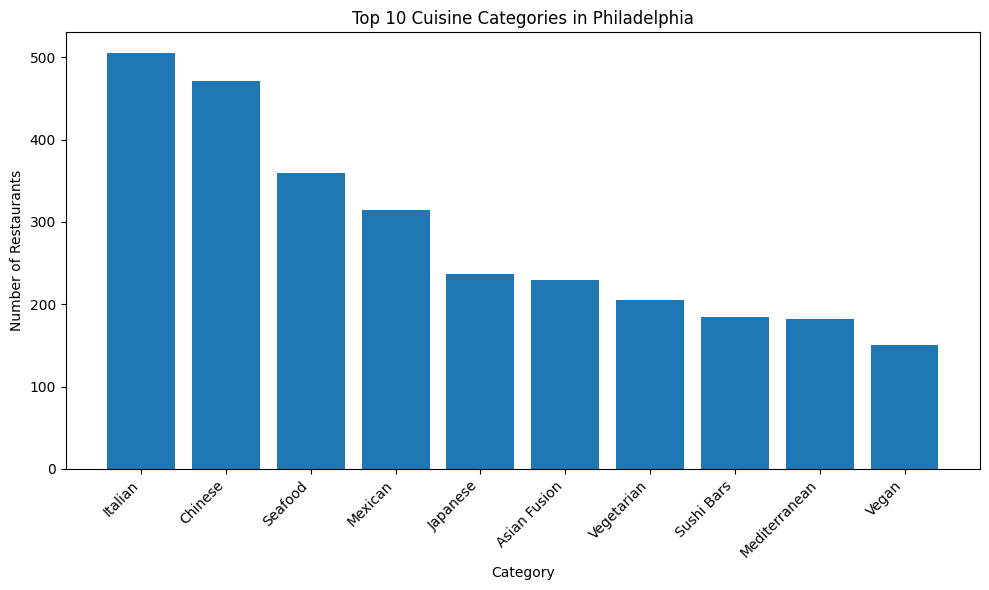

In [18]:
import matplotlib.pyplot as plt

top_categories = category_stats.sort_values('restaurant_count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_categories['category'], top_categories['restaurant_count'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Cuisine Categories in Philadelphia')
plt.xlabel('Category')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

This visualization highlights the most common cuisine categories in the Philadelphia restaurant market. Categories with the highest number of restaurants indicate areas of strong demand but also intense competition. These segments are likely more saturated, making it harder for new entrants to differentiate. Understanding which categories dominate the market helps identify where competition is concentrated and where alternative positioning strategies may be needed.

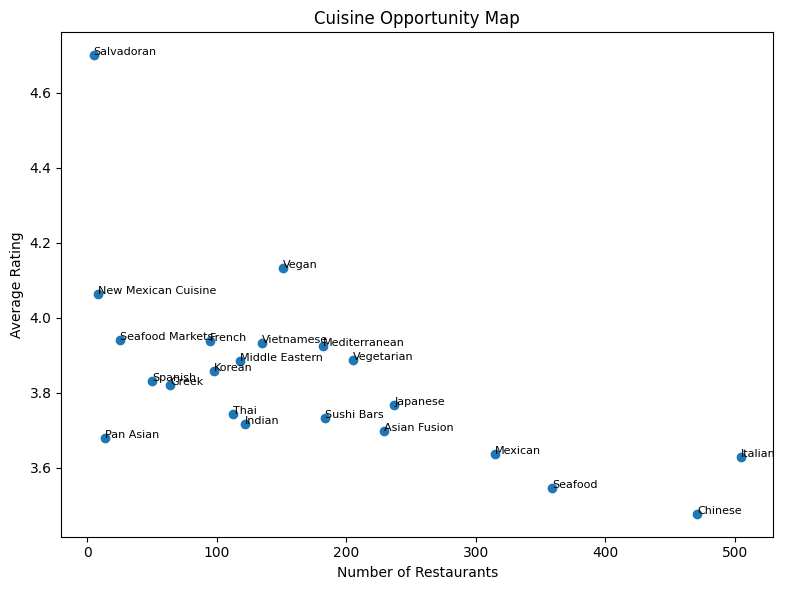

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(category_stats['restaurant_count'], category_stats['avg_rating'])

for _, row in category_stats.iterrows():
    plt.text(row['restaurant_count'], row['avg_rating'], row['category'], fontsize=8)

plt.title('Cuisine Opportunity Map')
plt.xlabel('Number of Restaurants')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

This visualization compares the level of competition and customer satisfaction across different cuisine categories. The number of restaurants represents how crowded each segment is, while the average rating reflects how well those categories meet customer expectations. Categories with high competition and lower ratings may indicate inconsistent quality, suggesting opportunities for differentiation. In contrast, categories with strong ratings but fewer competitors may represent underserved segments with potential for market entry.

## Final Recommendation

Initially, we planned to analyze Los Angeles, but due to limited data availability in the dataset, we shifted our focus to Philadelphia.

Our analysis shows that Philadelphia has a highly competitive restaurant market, with over 5,800 restaurants. However, the average rating is only around 3.56, indicating that many restaurants offer moderate quality and there is room for improvement.

We also found that while popular categories such as American, Pizza, and Sandwiches dominate the market, they are highly saturated. In contrast, some less common categories have higher average ratings but lower competition, suggesting potential opportunities.

Additionally, Asian-related cuisines already have a strong presence and generally receive good ratings, indicating that customers are receptive to these offerings.

Therefore, we recommend opening a mid-priced Asian fusion restaurant that focuses on high quality and differentiation. Incorporating modern trends such as plant-based or vegan-friendly options can further enhance competitiveness and appeal to younger customers.

This strategy allows the restaurant to enter a competitive market while standing out through quality and innovation.